In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=2, suppress=True)
pd.options.display.float_format = '{:.2f}'.format

In [183]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [184]:
train_df = pd.read_csv('data/train.csv')
train_df.shape
train_df.head()

(10000, 17)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.00,1.50,1.00,N,212,237,Credit Card,5.00,6.53,0.00,1.00,24.80,2.50,0.00
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.00,3.80,1.00,N,6,163,Credit Card,5.00,9.19,0.00,1.00,31.55,2.50,0.00
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.00,1.89,1.00,N,35,81,Credit Card,2.50,6.79,0.00,1.00,24.84,2.50,0.00
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.00,1.10,1.00,N,46,99,Credit Card,1.00,3.70,0.00,1.00,13.45,2.50,0.00
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.00,2.84,1.00,N,213,114,Credit Card,2.50,7.84,0.00,1.00,29.88,2.50,0.00


In [185]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

### Categorical data analysis

In [186]:
train_df['tpep_pickup_datetime'] = pd.to_datetime(train_df['tpep_pickup_datetime'])
train_df['tpep_dropoff_datetime'] = pd.to_datetime(train_df['tpep_dropoff_datetime'])

train_df['tpep_pickup_datetime'].head(2)
train_df['tpep_dropoff_datetime'].head(2)

0   2023-06-28 17:31:46
1   2023-06-29 19:15:55
Name: tpep_pickup_datetime, dtype: datetime64[ns]

0   2023-06-28 18:22:12
1   2023-06-29 19:07:31
Name: tpep_dropoff_datetime, dtype: datetime64[ns]

In [187]:
train_df['RatecodeID'].value_counts()

RatecodeID
1.00     9057
2.00      401
3.00       58
5.00       51
99.00      36
4.00       31
Name: count, dtype: int64

In [188]:
train_df['payment_type'].value_counts()
train_df['payment_type'].isna().sum()

payment_type
Credit Card    7727
Cash           1706
Wallet          366
unknown         133
UPI              68
Name: count, dtype: int64

np.int64(0)

In [189]:
train_df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    9565
Y      69
Name: count, dtype: int64

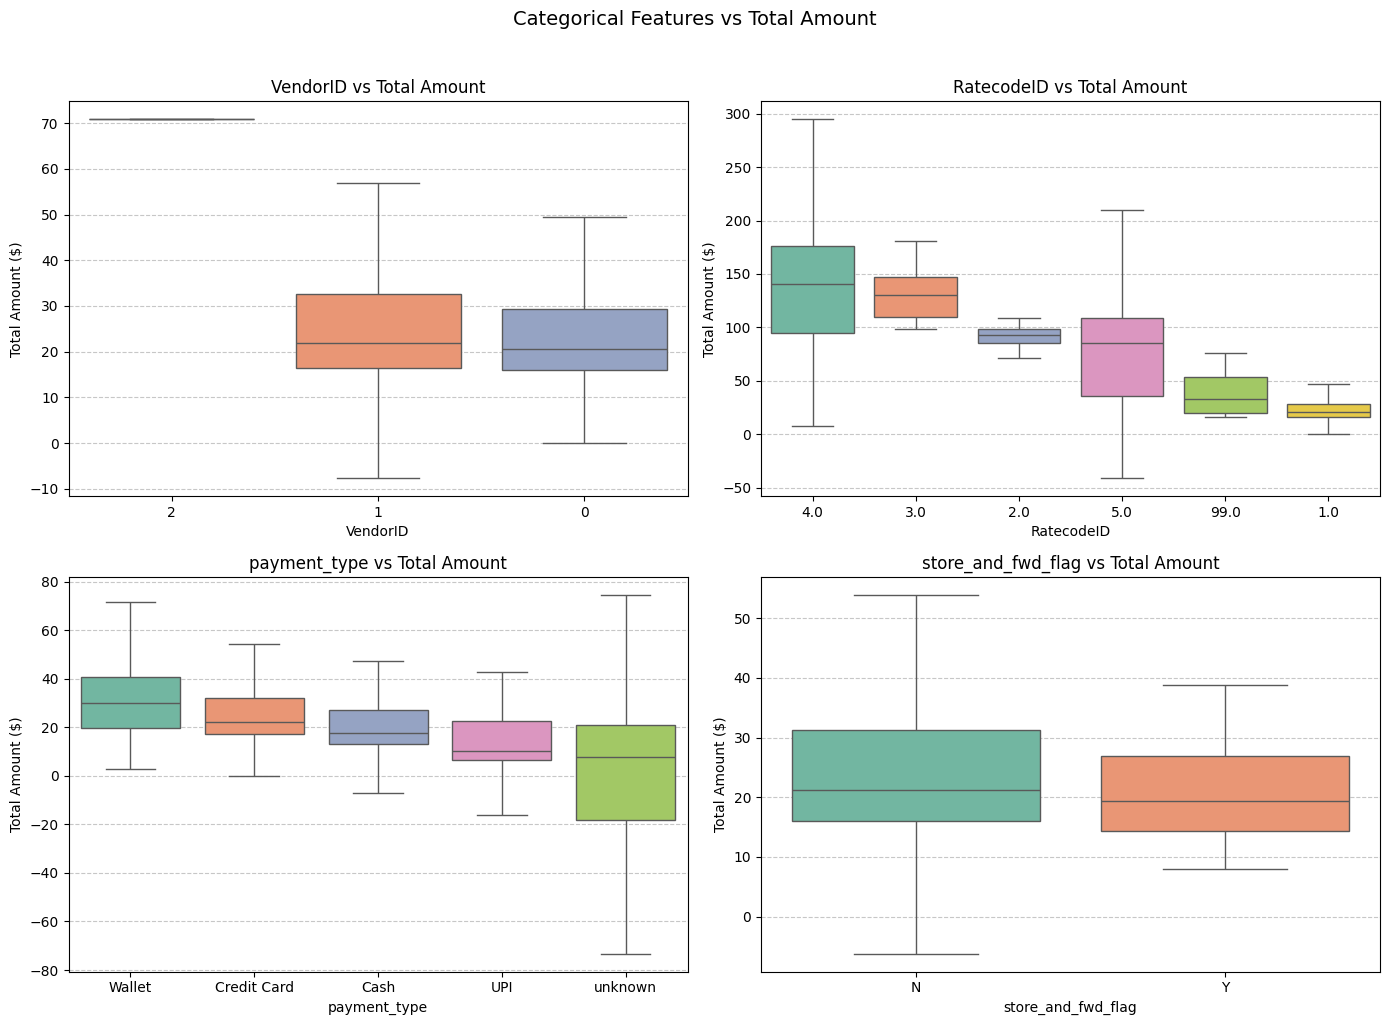

In [190]:
cat_cols_to_plot = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
  order = train_df.groupby(col)['total_amount'].median().sort_values(ascending=False).index
  _ = sns.boxplot(
      data=train_df,
      x=col,
      y='total_amount',
      order=order,
      palette='Set2',
      ax=axes[i],
      showfliers=False   # hide extreme outliers for readability
  )
  _ = axes[i].set_title(f'{col} vs Total Amount')
  _ = axes[i].set_xlabel(col)
  _ = axes[i].set_ylabel('Total Amount ($)')
  _ = axes[i].grid(axis='y', linestyle='--', alpha=0.7)

_ = plt.suptitle('Categorical Features vs Total Amount', fontsize=14, y=1.02)
_ = plt.tight_layout()

### Numerical data analysis

In [191]:
train_df['passenger_count'].value_counts()

passenger_count
1.00    7282
2.00    1424
3.00     357
4.00     197
0.00     173
5.00     119
6.00      82
Name: count, dtype: int64

In [192]:
print(f'tolls_amount: {train_df['tolls_amount'].describe()}')
print(f'improvement_surcharge: {train_df['improvement_surcharge'].describe()}')
print(f'tip_amount: {train_df['tip_amount'].describe()}')

tolls_amount: count   10000.00
mean        0.66
std         2.44
min       -26.55
25%         0.00
50%         0.00
75%         0.00
max        32.05
Name: tolls_amount, dtype: float64
improvement_surcharge: count   10000.00
mean        0.98
std         0.20
min        -1.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
Name: improvement_surcharge, dtype: float64
tip_amount: count   10000.00
mean        6.09
std         4.44
min         0.00
25%         3.47
50%         5.21
75%         7.46
max        84.03
Name: tip_amount, dtype: float64


### Analyzing missing values

In [193]:
train_df.isna().sum()

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

Dealing with null values Fill the null values with mean

In [194]:
# List of numerical columns identified in your dataset
numerical_cols = [
    'passenger_count', 'trip_distance', 'extra',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'Airport_fee'
]

# Impute nulls with the mean for each column
for col in numerical_cols:
  if col in train_df.columns:
    train_df[col] = train_df[col].fillna(train_df[col].mean())

# Specifically ensure passenger_count is an integer (cannot have 1.5 passengers)
train_df['passenger_count'] = train_df['passenger_count'].round().astype(int)

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='trip_distance', ylabel='total_amount'>

Text(0.5, 1.0, 'Relationship between Trip Distance and Total Amount')

Text(0.5, 0, 'Trip Distance (miles)')

Text(0, 0.5, 'Total Amount ($)')

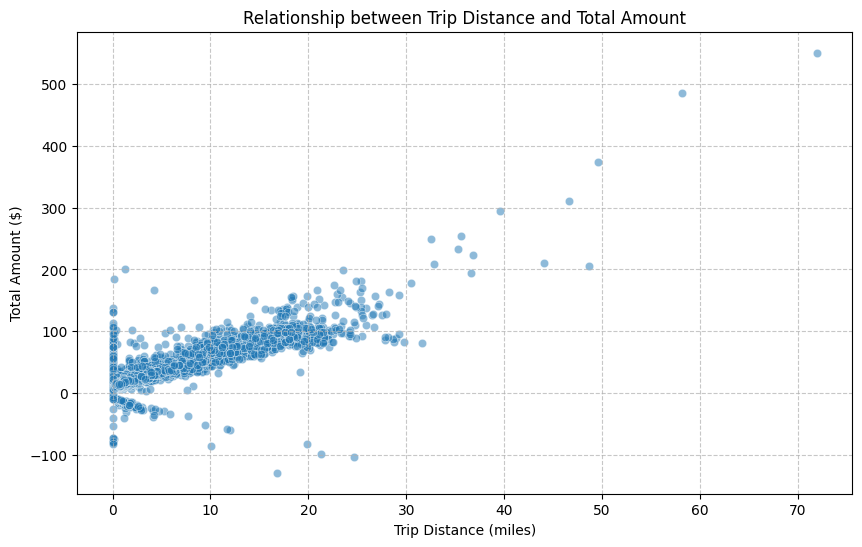

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='trip_distance', y='total_amount', alpha=0.5)

plt.title('Relationship between Trip Distance and Total Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Total Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot reveals a strong positive correlation between distance and fare. However, significant outliers exist, including negative fare amounts and zero-distance trips with high costs. To improve model accuracy, I will filter the dataset to remove negative fares and examine trips with zero distance before training

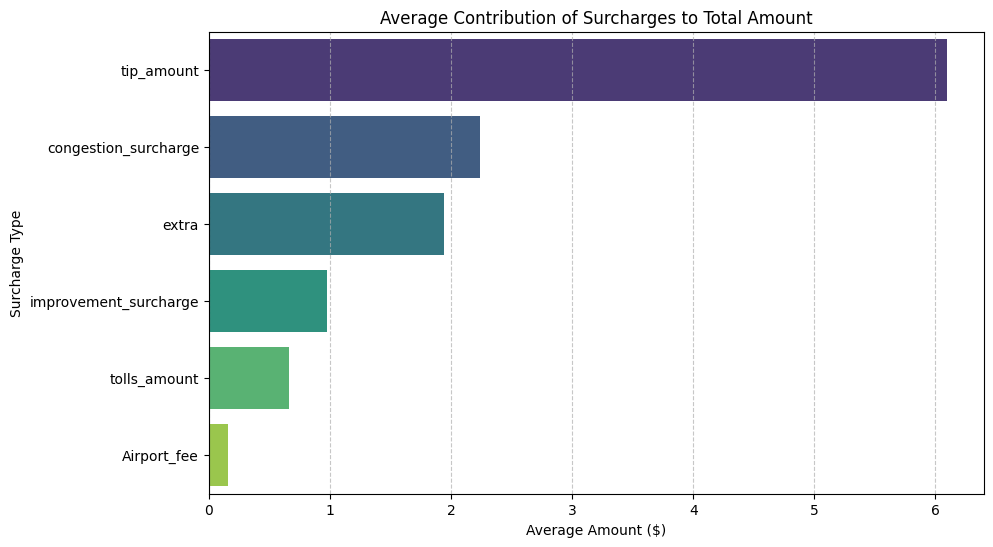

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of surcharge/additional fare columns
surcharge_cols = ['extra', 'tip_amount', 'tolls_amount',
                  'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']

# Calculate the mean value of each surcharge to see their relative impact
mean_surcharges = train_df[surcharge_cols].mean().sort_values(ascending=False)

_ = plt.figure(figsize=(10, 6))
_ = sns.barplot(x=mean_surcharges.values, y=mean_surcharges.index, palette='viridis')

_ = plt.title('Average Contribution of Surcharges to Total Amount')
_ = plt.xlabel('Average Amount ($)')
_ = plt.ylabel('Surcharge Type')
_ = plt.grid(axis='x', linestyle='--', alpha=0.7)

In [197]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1")
if not DATA_DIR.exists():
  DATA_DIR = Path("./data")

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

time_arr = ['tpep_pickup_datetime', 'tpep_dropoff_datetime',
            'tpep_pickup_datetime', 'tpep_dropoff_datetime',]

for time in time_arr:
  train_df[time] = pd.to_datetime(train_df[time])

print("Data loaded.")
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Data loaded.
Train: (10000, 17), Test: (1500, 17)


## Data Cleaning
### Drop Duplicates

In [198]:
before = len(train_df)
train_df = train_df.drop_duplicates()
print(f"Duplicates removed: {before - len(train_df)}")
print(f"Shape after: {train_df.shape}")

Duplicates removed: 0
Shape after: (10000, 17)


### Handle Outliers

In [199]:
before = len(train_df)

train_df = train_df[train_df['trip_distance'] > 0]
train_df = train_df[train_df['total_amount'] > 0]
if 'fare_amount' in train_df.columns:
  train_df = train_df[train_df['fare_amount'] >= 0]

print(f"Rows removed: {before - len(train_df)}")
print(f"Shape after: {train_df.shape}")
print("Remaining outliers retained. Tree-based models handle them natively.")

Rows removed: 242
Shape after: (9758, 17)
Remaining outliers retained. Tree-based models handle them natively.


## Preprocessing
### Define Features


In [200]:
TARGET = 'total_amount'

drop_cols = ['id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']
feature_cols = [c for c in train_df.columns if c not in drop_cols + [TARGET]]

X = train_df[feature_cols].copy()
y = train_df[TARGET].copy()

print(f"Feature count: {len(feature_cols)}")
print(feature_cols)

Feature count: 14
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']


### Encode Categorical Features

In [201]:
# store_and_fwd_flag is binary — label encode
if 'store_and_fwd_flag' in X.columns:
  X['store_and_fwd_flag'] = X['store_and_fwd_flag'].map({'Y': 1, 'N': 0})

# VendorID, RatecodeID, payment_type are already integers — no encoding needed
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Remaining object columns: {cat_cols}")

if cat_cols:
  X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Encoding done.")

Remaining object columns: ['payment_type']
Encoding done.


### Impute Remaining Nulls

In [202]:
for col in X.columns:
  if X[col].isnull().any():
    if X[col].dtype in ['float64', 'int64']:
      X[col] = X[col].fillna(X[col].median())
    else:
      X[col] = X[col].fillna(X[col].mode()[0])

print(f"Nulls remaining: {X.isnull().sum().sum()}")

Nulls remaining: 0


### Scale Features

In [203]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("StandardScaler applied.")
print("Scaled X for: LinearRegression, Ridge, Lasso, KNN.")
print("Unscaled X for: DecisionTree, RandomForest, GradientBoosting.")

StandardScaler applied.
Scaled X for: LinearRegression, Ridge, Lasso, KNN.
Unscaled X for: DecisionTree, RandomForest, GradientBoosting.


### Train-Validation Split

In [204]:
from sklearn.model_selection import train_test_split

X_tr,   X_val,   y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr_s, X_val_s, _,   _ = train_test_split(X_scaled,  y, test_size=0.2, random_state=42)

print(f"Train: {X_tr.shape}, Val: {X_val.shape}")

Train: (7806, 17), Val: (1952, 17)


# Model Building

In [205]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

results = {}


def fit_eval(name, model, X_tr, X_v, y_tr, y_v):
  model.fit(X_tr, y_tr)
  score = r2_score(y_v, model.predict(X_v))
  results[name] = round(score, 4)
  print(f"{name}: R2 = {score:.4f}")
  return model

In [206]:
m_lr = fit_eval("LinearRegression",  LinearRegression(),
                X_tr_s, X_val_s, y_tr, y_val)
m_ridge = fit_eval("Ridge",             Ridge(alpha=1.0),
                   X_tr_s, X_val_s, y_tr, y_val)
m_lasso = fit_eval("Lasso",             Lasso(alpha=0.1),
                   X_tr_s, X_val_s, y_tr, y_val)
m_knn = fit_eval("KNN",               KNeighborsRegressor(
    n_neighbors=5),                         X_tr_s, X_val_s, y_tr, y_val)
m_dt = fit_eval("DecisionTree",      DecisionTreeRegressor(
    random_state=42),                     X_tr,   X_val,   y_tr, y_val)
m_rf = fit_eval("RandomForest",      RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1), X_tr, X_val, y_tr, y_val)
m_gb = fit_eval("GradientBoosting",  GradientBoostingRegressor(
    n_estimators=100, random_state=42), X_tr, X_val, y_tr, y_val)

LinearRegression: R2 = 0.9399
Ridge: R2 = 0.9399
Lasso: R2 = 0.9414
KNN: R2 = 0.9091
DecisionTree: R2 = 0.8510
RandomForest: R2 = 0.9445
GradientBoosting: R2 = 0.9570


# Hyperparameter Tuning

## Tuning - Ridge

In [207]:
from sklearn.model_selection import GridSearchCV

ridge_grid = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_tr_s, y_tr)
score = r2_score(y_val, ridge_grid.best_estimator_.predict(X_val_s))
results["Ridge_Tuned"] = round(score, 4)
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Ridge_Tuned R2: {score:.4f}")

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}, scoring='r2')

Best alpha: 100.0
Ridge_Tuned R2: 0.9420


## Tuning - Decision Tree

In [208]:
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [5, 10, 20, None], 'min_samples_split': [
        2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    cv=3, scoring='r2', n_jobs=-1, verbose=1
)
dt_grid.fit(X_tr, y_tr)
score = r2_score(y_val, dt_grid.best_estimator_.predict(X_val))
results["DecisionTree_Tuned"] = round(score, 4)
print(f"Best params: {dt_grid.best_params_}")
print(f"DecisionTree_Tuned R2: {score:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2', verbose=1)

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
DecisionTree_Tuned R2: 0.8671


## Tuning - Random Forest

In [209]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]},
    cv=3, scoring='r2', n_jobs=-1, verbose=1
)
rf_grid.fit(X_tr, y_tr)
score = r2_score(y_val, rf_grid.best_estimator_.predict(X_val))
results["RandomForest_Tuned"] = round(score, 4)
print(f"Best params: {rf_grid.best_params_}")
print(f"RandomForest_Tuned R2: {score:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
RandomForest_Tuned R2: 0.9445


## Model Comparison

In [210]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'R2_Score'])
results_df = results_df.sort_values('R2_Score', ascending=False).reset_index(drop=True)
display(results_df)

,Model,R2_Score
0,GradientBoosting,0.96
1,RandomForest,0.94
2,RandomForest_Tuned,0.94
3,Ridge_Tuned,0.94
4,Lasso,0.94
5,LinearRegression,0.94
6,Ridge,0.94
7,KNN,0.91
8,DecisionTree_Tuned,0.87
9,DecisionTree,0.85


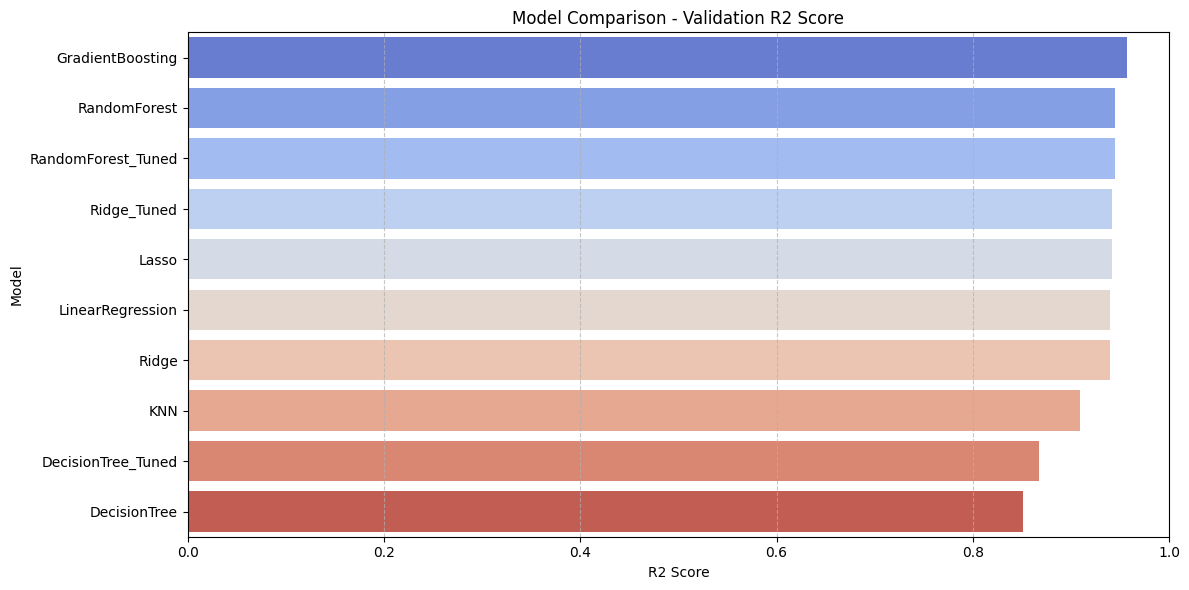

In [211]:
_ = plt.figure(figsize=(12, 6))
_ = sns.barplot(data=results_df, x='R2_Score', y='Model', palette='coolwarm')
_ = plt.title('Model Comparison - Validation R2 Score')
_ = plt.xlabel('R2 Score')
_ = plt.xlim(0, 1)
_ = plt.grid(axis='x', linestyle='--', alpha=0.7)
_ = plt.tight_layout()

## Test Preprocessing and Submission

In [212]:
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_test = test_df[feature_cols].copy()

if 'store_and_fwd_flag' in X_test.columns:
  X_test['store_and_fwd_flag'] = X_test['store_and_fwd_flag'].map({'Y': 1, 'N': 0})

cat_cols_test = X_test.select_dtypes(include='object').columns.tolist()
if cat_cols_test:
  X_test = pd.get_dummies(X_test, columns=cat_cols_test, drop_first=True)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

for col in X_test.columns:
  if X_test[col].isnull().any():
    X_test[col] = X_test[col].fillna(X_test[col].median())

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Test ready. Shape: {X_test.shape}")

Test ready. Shape: (1500, 17)


In [213]:
best_name = results_df.iloc[0]['Model']
print(f"Best model: {best_name}")

# Select model and feature set
scaled_names = ['LinearRegression', 'Ridge', 'Ridge_Tuned', 'Lasso', 'KNN']

if best_name == 'Ridge_Tuned':
  preds = ridge_grid.best_estimator_.predict(X_test_scaled)
elif best_name == 'DecisionTree_Tuned':
  preds = dt_grid.best_estimator_.predict(X_test)
elif best_name == 'RandomForest_Tuned':
  preds = rf_grid.best_estimator_.predict(X_test)
elif best_name in scaled_names:
  model_map = {'LinearRegression': m_lr, 'Ridge': m_ridge, 'Lasso': m_lasso, 'KNN': m_knn}
  preds = model_map[best_name].predict(X_test_scaled)
else:
  model_map = {'DecisionTree': m_dt, 'RandomForest': m_rf, 'GradientBoosting': m_gb}
  preds = model_map[best_name].predict(X_test)

submission = pd.DataFrame({'id': sample_sub['id'], 'total_amount': preds})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved.")
display(submission.head())

Best model: GradientBoosting
submission.csv saved.


,id,total_amount
0,0,16.99
1,1,25.67
2,2,26.02
3,3,22.13
4,4,13.88
